<h1 style="text-align: center;">SMT Challenge 2025 Catch Probability Model</h1>
<h3 style="text-align: center;"><i>Team 15</i> - this notebook is used to develop the catch probability model that will be used as a feature for the final model</h3>

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
pd.set_option('display.max_columns', None)

Helper Functions

In [68]:
def info_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Displays information about the dataframe with # of missing values, unique numbers, datatypes, etc.
    
    Arguments: Dataframe
    """
    df = df.copy()
    dtype = df.dtypes
    num_unique = df.T.apply(lambda x: x.nunique(), axis=1)
    nan_total = df.isnull().sum()
    nan_percent = (df.isnull().sum()/df.isnull().count()*100)
    quality_df = pd.concat([nan_total, nan_percent, num_unique, dtype], axis=1, keys=['total_NaNs', 'NaN%', 'num_unique', 'dtypes'])
    display(quality_df)

Analysis + Model

In [87]:
catch_prob_df = pd.read_csv('catch_prob_params.csv').iloc[:, 1:].copy()

In [88]:
catch_prob_df = catch_prob_df.copy()
catch_prob_df.loc[:, 'player_attempt'] = catch_prob_df['player_attempt'].fillna(catch_prob_df['closest_fielder_to_catch_point'])
catch_prob_df.loc[:, 'distance_needed'] = np.where(catch_prob_df['player_attempt'] == 7, 
                                           catch_prob_df['distance_needed_7'],
                                           np.where(
                                               catch_prob_df['player_attempt'] == 8, 
                                               catch_prob_df['distance_needed_8'], 
                                               np.where(
                                                   catch_prob_df['player_attempt'] == 9, 
                                                   catch_prob_df['distance_needed_9'],
                                                   np.nan)))
catch_prob_df.loc[:, 'direction_angle'] = np.where(catch_prob_df['player_attempt'] == 7, 
                                           catch_prob_df['direction_angle_7'],
                                           np.where(
                                               catch_prob_df['player_attempt'] == 8, 
                                               catch_prob_df['direction_angle_8'], 
                                               np.where(
                                                   catch_prob_df['player_attempt'] == 9, 
                                                   catch_prob_df['direction_angle_9'],
                                                   np.nan)))

## the ball deflection is off the first basemen instead of an outfielder --> we don't care for it then
catch_prob_df = catch_prob_df[catch_prob_df['game_str_id'] != 'y2_d083_WMI_YJD_231'].reset_index(drop=True).copy()
catch_prob_df

,game_str_id,distance_covered_7,distance_covered_8,distance_covered_9,opportunity_time,hang_time,direction_angle_7,direction_angle_8,direction_angle_9,distance_needed_7,distance_needed_8,distance_needed_9,sprint_speed_7,sprint_speed_8,sprint_speed_9,distance_to_wall,is_wall_ball,is_out_catch,closest_fielder_to_catch_point,player_attempt,whiffed_catch,play_per_game,game_str,top_bottom_inning,left_field,center_field,right_field,distance_needed,direction_angle
0,y1_d001_CGA_QEA_2,0.047809,0.159436,0.053226,0.55,0.10,"[300º, 330º)","[330º, 360º)","[0º, 30º)",258.845879,297.489448,267.759715,0.478089,1.594362,0.532265,322.225136,0,0.0,7.0,7.0,NaN,2.0,y1_d001_CGA_QEA,top,QEA-0249,QEA-0235,QEA-0252,258.845879,"[300º, 330º)"
1,y1_d001_CGA_QEA_4,17.456512,3.597757,2.737290,2.50,2.05,"[300º, 330º)","[30º, 60º)","[60º, 90º)",62.164670,130.364146,214.368285,13.271847,2.856124,1.575849,120.506207,0,0.0,7.0,7.0,NaN,4.0,y1_d001_CGA_QEA,top,QEA-0249,QEA-0235,QEA-0252,62.164670,"[300º, 330º)"
2,y1_d001_CGA_QEA_28,26.238063,9.943512,5.118369,2.70,2.30,"[240º, 270º)","[0º, 30º)","[60º, 90º)",98.228489,55.994471,133.973899,15.443373,9.139410,2.458858,139.761710,0,0.0,8.0,8.0,NaN,28.0,y1_d001_CGA_QEA,bottom,CGA-1198,CGA-1547,CGA-1929,55.994471,"[0º, 30º)"
3,y1_d001_CGA_QEA_31,0.226124,0.142909,0.085384,0.55,0.15,"[330º, 360º)","[0º, 30º)","[0º, 30º)",262.902638,288.027255,258.422720,1.507491,0.952729,0.569226,315.092680,0,0.0,9.0,9.0,NaN,31.0,y1_d001_CGA_QEA,bottom,CGA-1198,CGA-1547,CGA-1929,258.422720,"[0º, 30º)"
4,y1_d001_CGA_QEA_36,9.154151,8.153150,8.804083,1.90,1.50,"[300º, 330º)","[330º, 360º)","[30º, 60º)",171.937913,141.183469,146.082732,7.922772,7.969879,8.266926,191.299152,0,0.0,8.0,8.0,NaN,36.0,y1_d001_CGA_QEA,bottom,CGA-1198,CGA-1547,CGA-1929,141.183469,"[330º, 360º)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6702,y2_d098_YJD_RZQ_248,0.388828,0.899829,10.225631,2.35,1.90,"[270º, 360º)","[300º, 330º)","[0º, 30º)",240.147624,156.115780,80.072970,0.282541,0.645097,7.098930,117.512740,0,0.0,9.0,9.0,NaN,248.0,y2_d098_YJD_RZQ,bottom,YJD-0185,YJD-0019,YJD-0397,80.072970,"[0º, 30º)"
6703,y2_d098_YJD_RZQ_250,32.761575,31.217359,9.224948,3.10,2.65,"[270º, 360º)","[30º, 60º)","[60º, 90º)",47.737070,121.947383,216.807714,17.700201,17.436822,4.640462,167.275734,0,0.0,7.0,7.0,NaN,250.0,y2_d098_YJD_RZQ,bottom,YJD-0185,YJD-0019,YJD-0397,47.737070,"[270º, 360º)"
6704,y2_d098_YJD_RZQ_253,23.737511,28.662987,5.889720,2.50,2.10,"[300º, 330º)","[0º, 30º)","[60º, 90º)",87.394759,118.882795,194.680198,17.273720,18.574789,4.044085,197.800682,0,0.0,7.0,7.0,NaN,253.0,y2_d098_YJD_RZQ,bottom,YJD-0185,YJD-0019,YJD-0397,87.394759,"[300º, 330º)"
6705,y2_d098_YJD_RZQ_259,46.455297,26.214726,9.366749,3.95,3.55,"[60º, 90º)","[30º, 60º)","[60º, 90º)",40.425276,171.574104,293.317779,17.857625,10.940793,3.935888,247.811790,0,1.0,7.0,7.0,NaN,259.0,y2_d098_YJD_RZQ,bottom,YJD-0185,YJD-0019,YJD-0397,40.425276,"[60º, 90º)"


In [ ]:
sampled_catch_prob_df = catch_prob_df[['game_str_id', 'opportunity_time', 'distance_to_wall', 'distance_needed', 'direction_angle', 'is_out_catch', 'is_wall_ball']]

In [119]:
catch_prob_df[catch_prob_df['direction_angle'] == '[90º, 120º)']

,game_str_id,distance_covered_7,distance_covered_8,distance_covered_9,opportunity_time,hang_time,direction_angle_7,direction_angle_8,direction_angle_9,distance_needed_7,distance_needed_8,distance_needed_9,sprint_speed_7,sprint_speed_8,sprint_speed_9,distance_to_wall,is_wall_ball,is_out_catch,closest_fielder_to_catch_point,player_attempt,whiffed_catch,play_per_game,game_str,top_bottom_inning,left_field,center_field,right_field,distance_needed,direction_angle
11,y1_d001_CGA_QEA_108,11.900751,45.112443,54.988269,3.850,3.400,"[240º, 270º)","[270º, 360º)","[90º, 120º)",211.456035,105.098573,53.147946,4.219065,19.238452,22.903807,76.743508,0,0.0,9.0,9.0,NaN,108.0,y1_d001_CGA_QEA,top,QEA-0249,QEA-0235,QEA-0252,53.147946,"[90º, 120º)"
16,y1_d001_CGA_QEA_133,77.897596,78.170911,2.047836,5.050,4.600,"[180º, 210º)","[90º, 120º)","[90º, 120º)",104.779253,76.939585,231.911383,21.985109,21.906970,0.773452,13.509318,0,1.0,8.0,8.0,NaN,133.0,y1_d001_CGA_QEA,bottom,CGA-1198,CGA-1547,CGA-1929,76.939585,"[90º, 120º)"
21,y1_d001_CGA_QEA_212,7.701446,25.416239,39.050302,3.300,2.850,"[270º, 360º)","[300º, 330º)","[90º, 120º)",197.782020,86.292139,39.243907,4.135617,12.177094,19.144136,112.766417,0,1.0,9.0,9.0,NaN,212.0,y1_d001_CGA_QEA,top,QEA-0249,QEA-0235,QEA-0252,39.243907,"[90º, 120º)"
71,y1_d004_CGA_QEA_60,69.027506,61.464358,11.865575,4.620,4.191,"[210º, 240º)","[90º, 120º)","[90º, 120º)",103.233563,58.431848,188.370557,14.510850,13.840916,2.414849,47.133799,0,1.0,8.0,8.0,NaN,60.0,y1_d004_CGA_QEA,bottom,CGA-1353,CGA-1547,CGA-1929,58.431848,"[90º, 120º)"
90,y1_d005_JJS_YJD_31,30.134123,23.763899,4.876102,3.069,2.640,"[90º, 120º)","[60º, 90º)","[90º, 120º)",21.002052,150.086108,272.169044,9.716892,6.665557,1.158419,34.612722,0,1.0,7.0,7.0,NaN,31.0,y1_d005_JJS_YJD,bottom,JJS-2238,JJS-1625,JJS-2128,21.002052,"[90º, 120º)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6565,y2_d094_QZE_RZQ_6,63.995378,70.978339,45.189802,5.550,5.150,"[180º, 210º)","[90º, 120º)","[90º, 120º)",90.145397,63.569986,216.140701,19.208566,21.118290,11.932302,98.155543,0,1.0,8.0,8.0,NaN,6.0,y2_d094_QZE_RZQ,top,RZQ-0231,RZQ-0409,RZQ-0279,63.569986,"[90º, 120º)"
6605,y2_d095_QZE_RZQ_74,75.313656,69.795371,18.945515,5.550,5.100,"[180º, 210º)","[90º, 120º)","[90º, 120º)",98.843440,90.029946,259.253355,22.638932,23.016924,4.536175,103.784024,0,0.0,8.0,8.0,NaN,74.0,y2_d095_QZE_RZQ,top,RZQ-0275,RZQ-0409,RZQ-0231,90.029946,"[90º, 120º)"
6622,y2_d095_QZE_RZQ_223,11.004638,28.957447,1.326440,3.350,2.900,"[90º, 120º)","[60º, 90º)","[60º, 90º)",8.335973,144.342199,250.643639,6.118208,13.065649,0.806922,196.086900,0,1.0,7.0,7.0,NaN,223.0,y2_d095_QZE_RZQ,bottom,QZE-2217,QZE-1638,QZE-2280,8.335973,"[90º, 120º)"
6639,y2_d096_QZE_RZQ_56,86.236395,98.937671,22.574826,5.478,5.049,"[180º, 210º)","[90º, 120º)","[90º, 120º)",105.153377,88.648366,230.965483,15.447670,18.909220,5.404589,105.130962,0,1.0,8.0,8.0,NaN,56.0,y2_d096_QZE_RZQ,top,RZQ-0275,RZQ-0409,RZQ-0231,88.648366,"[90º, 120º)"


In [89]:
catch_prob_df['is_out_catch'].value_counts(normalize=True)

is_out_catch
0.0    0.529596
1.0    0.470404
Name: proportion, dtype: float64

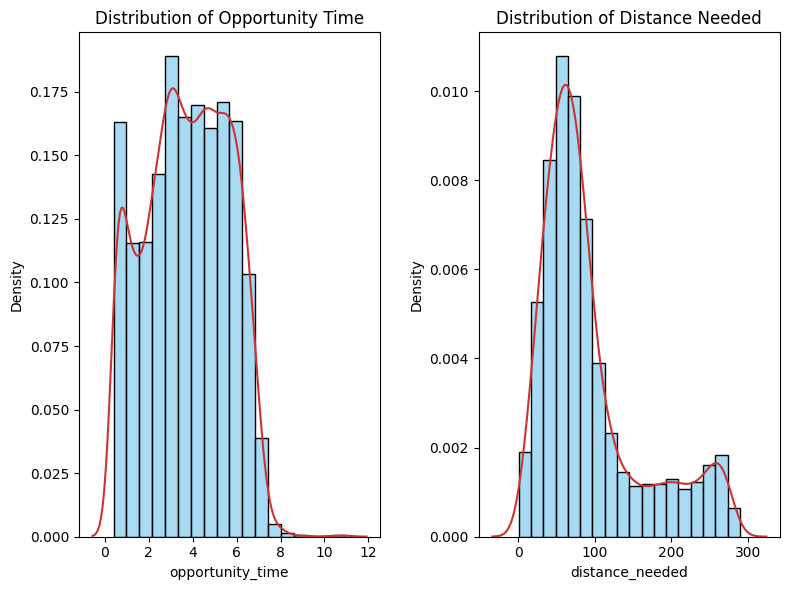

In [114]:
## Plots of our models's features' histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))
sns.histplot(data=catch_prob_df, x='opportunity_time', stat='density', bins=18, color='#89CFF0', ax=ax1)
sns.kdeplot(data=catch_prob_df, x='opportunity_time', color='#CC3433', ax=ax1)
ax1.set_title('Distribution of Opportunity Time')
sns.histplot(data=catch_prob_df, x='distance_needed', stat='density', bins=18, color='#89CFF0', ax=ax2)
sns.kdeplot(data=catch_prob_df, x='distance_needed', color='#CC3433', ax=ax2)
ax2.set_title('Distribution of Distance Needed')
plt.tight_layout()
plt.show()

In [122]:
direction_angle_cp = {i: np.mean(catch_prob_df[catch_prob_df['direction_angle'] == i]['is_out_catch']) for i in catch_prob_df['direction_angle'].unique()}
dict(sorted(direction_angle_cp.items(), key=lambda x: x[1]))

{'[330º, 360º)': 0.2502134927412468,
 '[0º, 30º)': 0.281431334622824,
 '[300º, 330º)': 0.32523148148148145,
 '[30º, 60º)': 0.34972677595628415,
 '[270º, 360º)': 0.5609756097560976,
 '[60º, 90º)': 0.6090225563909775,
 '[150º, 180º)': 0.711340206185567,
 '[180º, 210º)': 0.7198795180722891,
 '[90º, 120º)': 0.7487046632124352,
 '[210º, 240º)': 0.75,
 '[240º, 270º)': 0.7594202898550725,
 '[120º, 150º)': 0.7834394904458599}

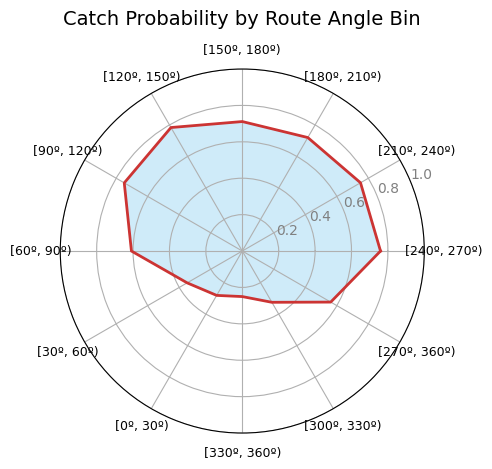

In [139]:
ordered_labels = [
    '[240º, 270º)',  # 0º–30º (straight ahead)
    '[210º, 240º)',  # 30º–60º
    '[180º, 210º)',  # 60º–90º
    '[150º, 180º)',  # 90º–120º
    '[120º, 150º)',  # 120º–150º
    '[90º, 120º)',   # 150º–180º
    '[60º, 90º)',    # 180º–210º
    '[30º, 60º)',    # 210º–240º
    '[0º, 30º)',     # 240º–270º
    '[330º, 360º)',  # 270º–300º
    '[300º, 330º)',  # 300º–330º
    '[270º, 360º)'   # 330º–360º
]
assert all(label in direction_angle_cp for label in ordered_labels)

# Values in that order
values = [direction_angle_cp[label] for label in ordered_labels]

# Close the loop for radar plot
values += values[:1]
angles = [n / float(len(ordered_labels)) * 2 * np.pi for n in range(len(ordered_labels))]
angles += angles[:1]

# Plot
plt.figure(figsize=(5, 5))
ax = plt.subplot(111, polar=True)

# Labels on axes
plt.xticks(angles[:-1], ordered_labels, size=9)

# Plot line
ax.plot(angles, values, linewidth=2, linestyle='solid', color='#CC3433')
ax.fill(angles, values, color='#89CFF0', alpha=0.4)

# Y-axis settings
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], color="gray")
ax.set_ylim(0, 1)

# Make front-facing (0°) at top
ax.set_theta_zero_location("E")   # 0º = top
ax.set_theta_direction(1)        # clockwise

plt.title("Catch Probability by Route Angle Bin", y=1.1, fontsize=14)
plt.tight_layout()
plt.show()

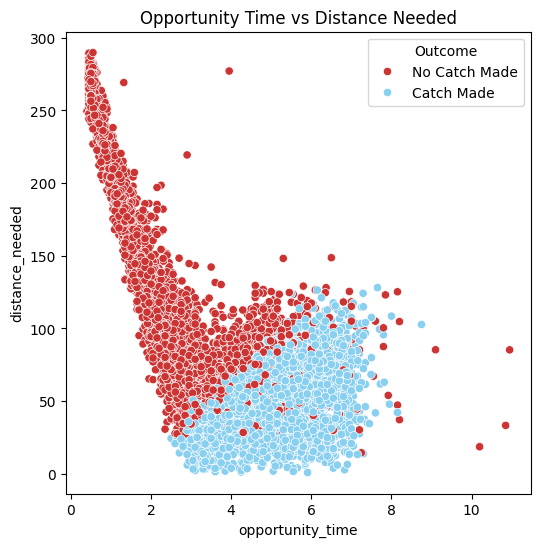

In [ ]:
plt.figure(figsize=(6, 6))
scatter_plot = sns.scatterplot(data=catch_prob_df, x='opportunity_time', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
handles, labels = scatter_plot.get_legend_handles_labels()
scatter_plot.legend(handles=handles, labels=['No Catch Made', 'Catch Made'], title='Outcome')
plt.title('Opportunity Time vs Distance Needed')
plt.show()

Catch Probability GAM Results

In [112]:
from sklearn.model_selection import train_test_split
from pygam import LogisticGAM, s

np.random.seed(42)

X = catch_prob_df[['opportunity_time', 'distance_needed']].values
y = catch_prob_df['is_out_catch'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

gam = LogisticGAM(s(0) + s(1)).fit(X_train, y_train)
y_pred_proba = gam.predict_proba(X_test)
y_pred = gam.predict(X_test)
gam.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     12.2688
Link Function:                        LogitLink Log Likelihood:                                   -786.515
Number of Samples:                         4024 AIC:                                             1597.5678
                                                AICc:                                            1597.6622
                                                UBRE:                                               2.3994
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.7173
Feature Function                  Lam

/var/folders/6l/fh4ck8px62x4x7vp3j9kjr6h0000gn/T/ipykernel_28588/1317582840.py:15: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


Catch Probability GAM Results

In [113]:
probs_df = pd.DataFrame({'opportunity_time': X_test[:, 0],
                         'distance_needed': X_test[:, 1],
                         'predicted': np.array([i for i in y_pred]),
                         'predicted_prob': np.array([round((i*100)/5)*5 for i in y_pred_proba]),
                         'actual_outcome': y_test}
                         )
probs_df

,opportunity_time,distance_needed,predicted,predicted_prob,actual_outcome
0,6.250,95.703432,True,75,1.0
1,1.050,213.855145,False,0,0.0
2,0.750,240.174457,False,0,0.0
3,7.000,21.244582,True,100,1.0
4,3.450,62.126814,False,15,0.0
...,...,...,...,...,...
1337,3.050,117.305945,False,0,0.0
1338,2.145,100.258183,False,0,0.0
1339,6.700,68.078609,True,100,1.0
1340,4.100,80.820295,False,15,0.0


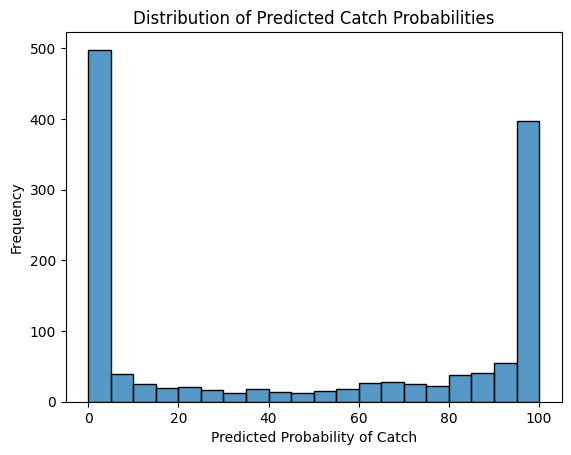

In [107]:
import matplotlib.pyplot as plt

sns.histplot(data=probs_df, x='predicted_prob', bins=20, edgecolor='k')
plt.xlabel('Predicted Probability of Catch')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Catch Probabilities')
plt.show()